# Capítulo 3: Análise Exploratória de Dados - AED
Este notebook replica as principais implementações práticas de tabelas e gráficos discutidos no Capítulo 3 do livro *Estatística para Cursos de Engenharia, Computação e Ciência de Dados*.

Com o advento da informática, o mundo passou a produzir muitos dados. As empresas têm dados de suas atividades, de seus funcionários, de seus clientes etc. Mas para que esses dados sejam informativos, necessitamos organizá-los, resumi-los e apresentá-los de forma adequada. Este é o papel da análise exploratória de dados e da estatística descritiva.

Como ilustração, considere o processo de pasteurização de leite em um laticínio, no qual os engenheiros estão preocupados com a variação da temperatura do pasteurizador. Foram observadas 1.389 leituras de temperatura, em vários dias, horários e localização do termômetro.1 A Figura 3.1 mostra parte do conjunto das observações e um gráfico apresentando a distribuição de frequências de todas as leituras. Note que, pelo gráfico, você tem uma visão geral da variabilidade do processo, o que não ocorre ao olhar valor por valor das 1.389 leituras.

Na análise exploratória de dados, além de descrever os dados, buscamos conhecer algumas características do processo com base nos dados. Com o uso adequado de tabelas, gráficos e medidas podemos descobrir certas estruturas que não são evidentes nos dados brutos.

## Importando Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [8, 5]

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## Figura 3.1
Parte dos dados brutos e  gráfico de distribuição das frequências das leituras de temperatura de um pasteurizador

In [7]:
# Figura 3.1 Carregar os dados do exercício 3.1 - temperatura pasteurizador
fig3_1 = pd.read_excel('dat/barbetta/exercicios/Cap3exercicio3.xlsx')
fig3_1.rename(columns={'Sequencia': 'leitura', 'Temperatura do Pasteurizador': 'temperatura'}, inplace=True)

print("=" * 80)
print("Figura 3.1")
print("=" * 80)
display(fig3_1.head(10)) # primeiras 10 linhas

Figura 3.1


,leitura,temperatura
0,1,74.782973
1,2,73.789685
2,3,75.336285
3,4,76.385226
4,5,76.305837
5,6,76.849285
6,7,72.869102
7,8,74.850094
8,9,76.200835
9,10,73.983762


Replicar Tabela e Gráfico da Figura 3.1

Total de medições simuladas: 1389

Primeiras linhas da matriz de dados simulada:
 leit      temp
    1 73.469749
    2 75.408536
    3 77.757409
    4 76.484097
    5 74.449277
    6 75.188642
    7 76.987933
    8 74.545643
    9 74.289140
   10 74.950579


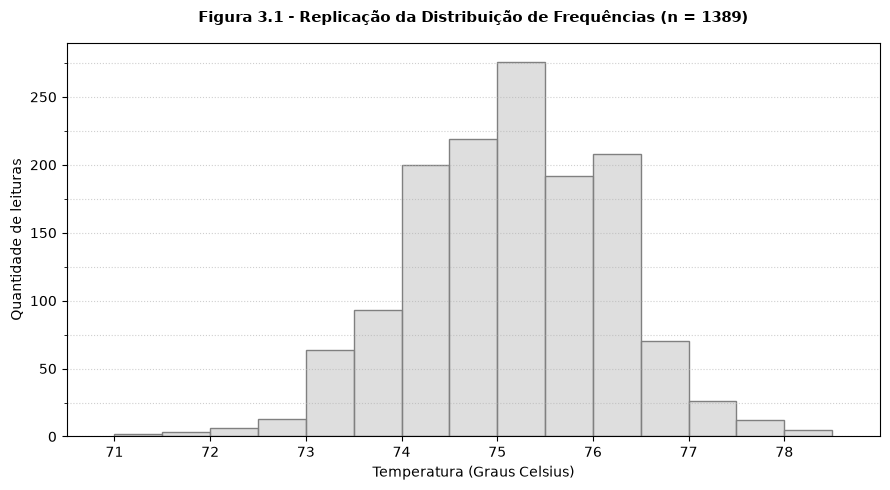

In [28]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
import pandas as pd
import seaborn as sns

# Configurando a semente aleatória para reprodutibilidade
np.random.seed(seed = 42)

# Frequências calculadas proporcionalmente ao desenho das barras da imagem
frequencias_classes = {
    (71.0, 71.5): 2,
    (71.5, 72.0): 3,
    (72.0, 72.5): 6,
    (72.5, 73.0): 13,
    (73.0, 73.5): 64,
    (73.5, 74.0): 93,
    (74.0, 74.5): 200,
    (74.5, 75.0): 219,
    (75.0, 75.5): 276,
    (75.5, 76.0): 192,
    (76.0, 76.5): 208,
    (76.5, 77.0): 70,
    (77.0, 77.5): 26,
    (77.5, 78.0): 12,
    (78.0, 78.5): 5,
    (78.5, 79.0): 0,
}

temperaturas_simuladas = []

# Gerando os dados uniformemente dentro de cada bin
for (lim_inf, lim_sup), qtd in frequencias_classes.items():
    valores = np.random.uniform(low = lim_inf, high = lim_sup, size = qtd)
    temperaturas_simuladas.extend(valores)

# Criando o DataFrame com as colunas 'leit' e 'temp'
df_simulado = pd.DataFrame(
    data = {
        "leit": range(1, len(temperaturas_simuladas) + 1),
        "temp": temperaturas_simuladas,
    }
)

# Embaralhando os dados para simular uma coleta de campo real
df_simulado = df_simulado.sample(frac = 1).reset_index(drop = True)
df_simulado["leit"] = df_simulado.index + 1

# Verificação do total de registros gerados
print(f"Total de medições simuladas: {len(df_simulado)}")
print("\nPrimeiras linhas da matriz de dados simulada:")
print(df_simulado.head(n = 10).to_string(index = False))

# --- Plotagem do Gráfico ---
plt.figure(figsize = (9, 5))

# Criando o histograma com intervalos de 1 em 1 grau
sns.histplot(
    data = df_simulado,
    x = "temp",
    bins = np.arange(71, df_simulado["temp"].max() + 0.5, 0.5),
    color = "#d3d3d3",
    edgecolor = "#808080",
)

# Customização dos eixos
plt.title(
    label = f"Figura 3.1 - Replicação da Distribuição de Frequências (n = {len(df_simulado)})",
    fontsize = 11,
    fontweight = "bold",
    pad = 15,
)
plt.xlabel(xlabel = "Temperatura (Graus Celsius)", fontsize = 10)
plt.ylabel(ylabel = "Quantidade de leituras", fontsize = 10)

# Configura o eixo X
plt.xticks(ticks = range(71, 79))
plt.xlim(left = 70.5, right = 79)

# Captura os eixos atuais para aplicar a paginação do eixo Y
ax = plt.gca()

# Define os labels/linhas principais a cada 50 e as linhas secundárias a cada 25
ax.yaxis.set_major_locator(MultipleLocator(50))
ax.yaxis.set_minor_locator(MultipleLocator(25))

# Aplica o grid pontilhado tanto nas linhas principais quanto nas secundárias
plt.grid(axis = "y", which = "both", linestyle = ":", alpha = 0.6)

plt.tight_layout()
plt.show()

## 3.1 DADOS E VARIÁVEIS
No exemplo anterior, os dados são observações da temperatura do pasteurizador. Em cada leitura (unidade de observação), tem-se um valor da variável temperatura.

Em geral, os dados são reunidos em arquivos, sob a forma matricial. As linhas correspondem ao que se observou em cada elemento pesquisado, enquanto as colunas correspondem às variáveis levantadas ou medidas.
  
EXEMPLO 3.1
  
Um aplicativo gratuito exige o cadastro de seus usuários. Isto porque o proprietário quer vender cotas de inserção de propagandas que serão exibidas de forma direcionada no aplicativo. Este cadastro solicita os seguintes dados: sexo, idade, nível de instrução e o provedor de internet que usa. Os dados ficarão armazenados em forma matricial, como mostra a Figura 3.2, em que cada linha tem o perfil de um usuário e cada coluna mostra as observações de uma variável. 


![FIGURA 3.2Exemplo de um conjunto de dados.](fig\dados_forma_matricial.png)

A figura acima ilustra um exemplo de um conjunto de dados (dataset).
  
Os dados podem ser observações de variáveis qualitativas ou quantitativas.

Quando os possíveis resultados de uma variável são números em certa escala, dizemos que a variável é quantitativa. Quando os possíveis resultados são atributos ou qualidades, a variável é dita qualitativa ou categórica.

No exemplo de usuários do aplicativo, o sexo, o nível de instrução e o provedor são variáveis qualitativas, enquanto a idade é quantitativa.

### Exemplo 3.1 - forma matricial de um dataset

In [32]:
# Exemplo 3.1 Carregar os dados
ex3_1 = pd.read_excel('dat/barbetta/exemplos/Exemplo_3_1.xlsx')
print("=" * 80)
print("Exemplo 3.1 e figura 3.2")
print("=" * 80)
display(ex3_1)

Exemplo 3.1 e figura 3.2


,Usuário,Sexo,idade,Nível de Instrução,Provedor
0,1,M,35,superior,C
1,2,F,18,fundamental,A
2,3,F,20,fundamental,B
3,4,F,40,médio,B
4,5,F,33,médio,C
5,6,M,21,fundamental,B
6,7,M,58,superior,D
7,8,M,30,fundamental,B
8,9,F,35,superior,B
9,10,M,25,médio,A


## Tabela 3.1
Distribuição de frequências do provedor usado pelo usuário do aplicativo

In [45]:
import pandas as pd

# ==============================================================================
# DISTRIBUIÇÃO DE FREQUÊNCIAS (PROVEDOR)
# ==============================================================================

# NOTA: Substitua 'provedor' pelo nome exato da coluna no seu arquivo Excel
nome_coluna_provedor = 'Provedor' 

# 1. Contagem da Frequência Absoluta (fi): quantidade de usuários por provedor
freq_absoluta = ex3_1[nome_coluna_provedor].value_counts().astype(int) # tratar como inteiro

# 2. Contagem da Frequência Relativa (fr): proporção de cada provedor (de 0 a 1)
freq_relativa = ex3_1[nome_coluna_provedor].value_counts(normalize=True)

# 3. Contagem da Frequência Percentual (fr%): proporção multiplicada por 100
freq_percentual = freq_relativa * 100

# 4. Construção da Tabela de Distribuição de Frequências
tabela_frequencias = pd.DataFrame({
    'Frequência Absoluta (fi)': freq_absoluta.astype(int), # Exibir apenas a parte inteira
    'Frequência Relativa (fr)': freq_relativa.round(4),
    'Frequência Percentual (fr%)': freq_percentual.round(2)
})

# 5. Adiciona uma linha de total no final da tabela para validação estatística
total_absoluto = freq_absoluta.sum() # tratar essa coluna em inteiro
total_relativo = freq_relativa.sum()
total_percentual = freq_percentual.sum()

# salvar a tabela de frequências
tabela_frequencias_sem_total = tabela_frequencias.copy()

# Adiciona a linha de total na tabela de frequências
tabela_frequencias.loc['Total'] = [total_absoluto, total_relativo, total_percentual]

# Converte a coluna inteira da tabela para int (evita que a linha 'Total' force o tipo float)
tabela_frequencias['Frequência Absoluta (fi)'] = tabela_frequencias['Frequência Absoluta (fi)'].astype(int)

# Exibe o resultado final formatado
print("\n" + "=" * 72)
print("Tabela de Distribuição de Frequências: Provedor do usuário do aplicativo")
print("=" * 72)
display(tabela_frequencias)



Tabela de Distribuição de Frequências: Provedor do usuário do aplicativo


,Frequência Absoluta (fi),Frequência Relativa (fr),Frequência Percentual (fr%)
Provedor,,,
B,17,0.425,42.5
A,10,0.250,25.0
C,7,0.175,17.5
D,6,0.150,15.0
Total,40,1.000,100.0


### 3. Representação Gráfica dos Dados do Exemplo 3.1

C:\Users\Cleuler\AppData\Local\Temp\ipykernel_27552\4182718115.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


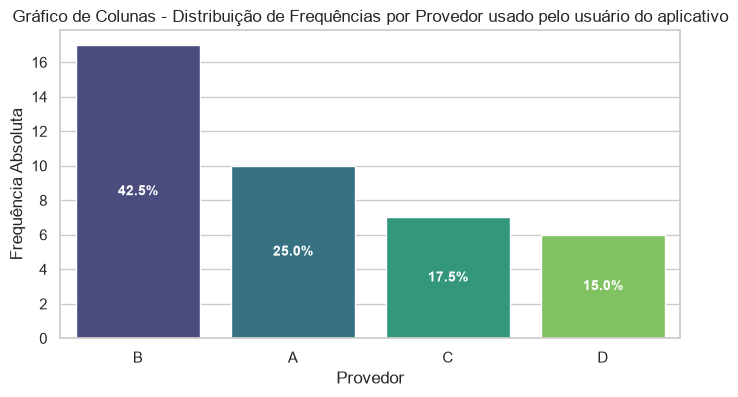

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configura o tamanho da figura
plt.figure(figsize=(8, 4))

# Cria o gráfico de barras salvando o objeto 'ax'
ax = sns.barplot(
    x=tabela_frequencias_sem_total.index,
    y='Frequência Absoluta (fi)',
    data=tabela_frequencias_sem_total, 
    palette='viridis'
)

# Configurações de títulos e rótulos
plt.title('Gráfico de Colunas - Distribuição de Frequências por Provedor usado pelo usuário do aplicativo')
plt.xlabel('Provedor')
plt.ylabel('Frequência Absoluta')

# Mapeia os índices do gráfico para buscar o percentual correto
categorias = [label.get_text() for label in ax.get_xticklabels()]

# Itera sobre cada barra (patch) do gráfico para desenhar o texto no interior
for i, patch in enumerate(ax.patches):
    # Obtém a largura e a altura da barra atual
    largura = patch.get_width()
    altura = patch.get_height()
    
    # Ignora barras vazias ou de altura zero
    if altura > 0:
        # Encontra a coordenada X (centro da barra) e Y (metade da altura da barra)
        x_pos = patch.get_x() + largura / 2
        y_pos = altura / 2
        
        # Busca o percentual correspondente à categoria atual da barra
        pct_valor = tabela_frequencias_sem_total.loc[categorias[i], 'Frequência Percentual (fr%)']
        texto_label = f"{pct_valor:.1f}%"
        
        # Insere o texto exatamente no centro interno da coluna
        ax.text(
            x=x_pos, 
            y=y_pos, 
            s=texto_label, 
            ha='center', 
            va='center', 
            color='white', 
            weight='bold',
            fontsize=10
        )

plt.show()

O mesmo gráfico anterior agora na forma de um gráfico de setores.

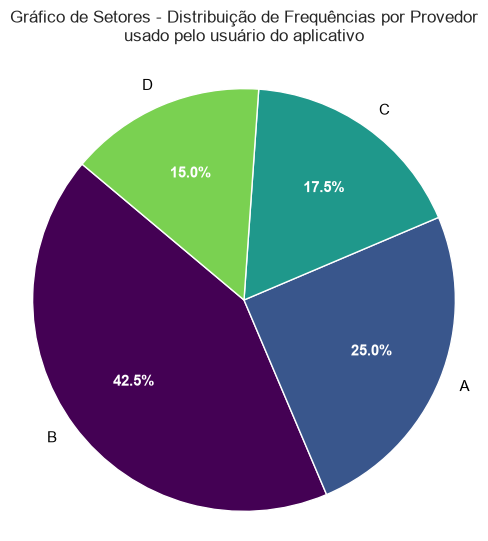

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Configura o tamanho da figura (um quadrado é ideal para gráficos circulares)
plt.figure(figsize=(6, 6))

# 2. Define a paleta de cores viridis para combinar com o gráfico anterior
# Criamos uma lista de cores com base no número de categorias existentes
num_categorias = len(tabela_frequencias_sem_total)
cores_viridis = plt.cm.viridis(np.linspace(0, 0.8, num_categorias))

# 3. Cria o gráfico de setores (pizza)
plt.pie(
    x=tabela_frequencias_sem_total['Frequência Absoluta (fi)'], # Valores das fatias
    labels=tabela_frequencias_sem_total.index,                   # Nomes dos provedores
    autopct='%1.1f%%',                                          # Formato do percentual interno
    pctdistance=0.65,                                           # Posição do texto (0 = centro, 1 = borda)
    colors=cores_viridis,                                       # Aplica as cores viridis
    startangle=140,                                             # Rotaciona o gráfico para melhor ângulo visual
    textprops={
        'color': 'white',                                       # Cor do texto percentual (branco)
        'weight': 'bold',                                       # Texto em negrito
        'fontsize': 11
    }
)

# 4. Ajusta a cor dos rótulos externos (nomes dos provedores) para preto
# O plt.pie por padrão aplica a mesma cor interna em tudo se não separarmos.
# Vamos garantir que os textos externos fiquem visíveis fora da pizza.
for text in plt.gca().texts:
    if '%' not in text.get_text():
        text.set_color('black')
        text.set_weight('normal')

# 5. Adiciona o título
plt.title(
    'Gráfico de Setores - Distribuição de Frequências por Provedor\nusado pelo usuário do aplicativo', 
    pad=20
)

# Garante que o gráfico seja desenhado como um círculo perfeito
plt.axis('equal') 

plt.show()

Alterar o gráfico de setores acima para exibir uma legenda à direita com as catgorias do Provedor

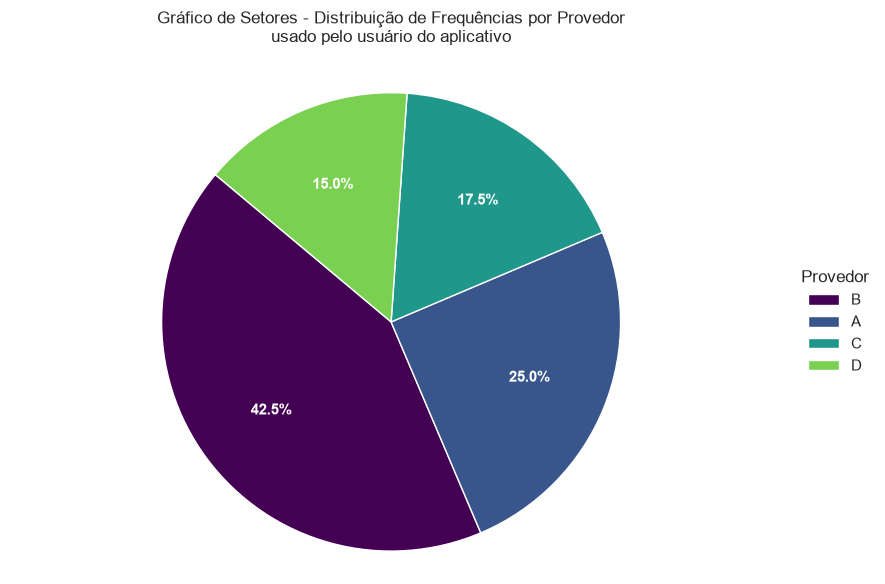

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Dados para o gráfico
valores = tabela_frequencias_sem_total['Frequência Absoluta (fi)']
categorias = tabela_frequencias_sem_total.index

# Configuração da figura
fig, ax = plt.subplots(figsize=(9, 6))
num_categorias = len(categorias)
cores_viridis = plt.cm.viridis(np.linspace(0, 0.8, num_categorias))

# Gráfico de setores sem rótulos externos (a legenda mostrará as categorias)
wedges, texts, autotexts = ax.pie(
    x=valores,
    labels=None,
    autopct='%1.1f%%',
    pctdistance=0.65,
    colors=cores_viridis,
    startangle=140,
    textprops={
        'color': 'white',
        'weight': 'bold',
        'fontsize': 11
    }
)

# Título e aspecto circular
ax.set_title(
    'Gráfico de Setores - Distribuição de Frequências por Provedor\nusado pelo usuário do aplicativo',
    pad=20
)
ax.axis('equal')

# Legenda posicionada à direita com as categorias do provedor
ax.legend(
    wedges,
    categorias,
    title='Provedor',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()

## Dagrama de Pareto
Uma das ferramentas dos programas de qualidade é o chamado diagrama de Pareto. A sua construção em si é bastante simples, pois corresponde ao gráfico de barras ou de colunas, mas com as categorias ordenadas de maneira decrescente pelas frequências observadas.

Esse diagrama é usado em postos de avaliação da qualidade para apresentar de forma clara os problemas decorrentes da falta da qualidade em ordem hierárquica de importância ou de frequência. A Figura 3.5 exemplifica esse diagrama na implantação de um controle integrado de processos. Neste exemplo, a priorização dos problemas foi feita pela frequência de ocorrências.

Observando a Figura 3.5, verificamos que as principais características que levam à falta de qualidade no posto de avaliação são a espessura, as rebarbas e as falhas no desenho. Um programa de melhoria da qualidade deve enfrentar prioritariamente essas características.

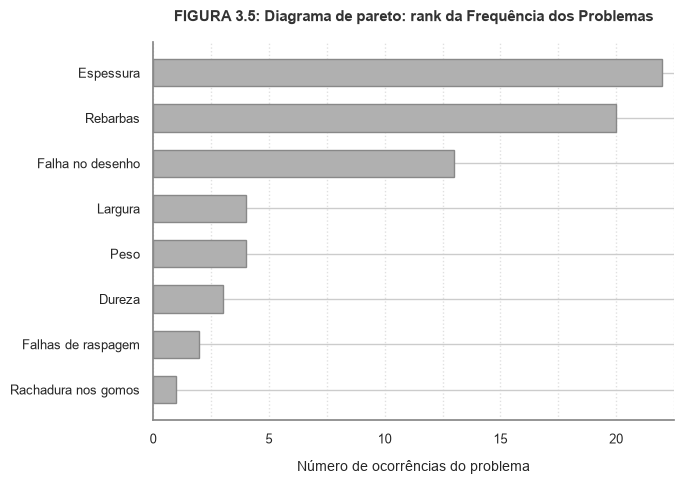

In [63]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
import pandas as pd
import seaborn as sns

# Configuração de estilo geral para parecer com livro técnico (tons de cinza)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#333333'

# =========================================================================
# FIGURA 3.5: Pareto por Frequência (Barras Horizontais)
# =========================================================================
fig1, ax1 = plt.subplots(figsize=(7, 5))

# Dados estimados a partir da imagem
categorias_35 = [
    'Espessura', 'Rebarbas', 'Falha no desenho', 'Largura', 
    'Peso', 'Dureza', 'Falhas de raspagem', 'Rachadura nos gomos'
]
frequencias_35 = [22, 20, 13, 4, 4, 3, 2, 1]

# Inverter a ordem para que o maior fique no topo no gráfico horizontal
categorias_35.reverse()
frequencias_35.reverse()

# Plotagem das barras
bars = ax1.barh(categorias_35, frequencias_35, color='#B0B0B0', edgecolor='#888888', height=0.6)

# Configurações dos eixos
ax1.set_xlabel('Número de ocorrências do problema', fontsize=10, labelpad=10)
ax1.set_xlim(0, 22.5)
ax1.set_xticks([0, 5, 10, 15, 20])
ax1.tick_params(axis='both', which='major', labelsize=9)

# Captura os eixos atuais para aplicar a paginação do eixo X
ax = plt.gca()

# Define os labels/linhas principais a cada 5 e as linhas secundárias a cada 2.5
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(2.5))

# Aplica o grid pontilhado tanto nas linhas principais quanto nas secundárias
plt.grid(axis = "x", which = "both", linestyle = ":", alpha = 0.6)

# Remover bordas desnecessárias (topo e direita)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#888888')
ax1.spines['bottom'].set_color('#888888')

plt.title('FIGURA 3.5: Diagrama de pareto: rank da Frequência dos Problemas', fontsize=11, weight='bold', pad=15)
plt.tight_layout()

No diagrama de Pareto, é mais comum priorizar os problemas de qualidade em termos financeiros. A Figura 3.6 ilustra esta situação, incluindo também uma curva que indica as perdas acumuladas pela falta de qualidade.

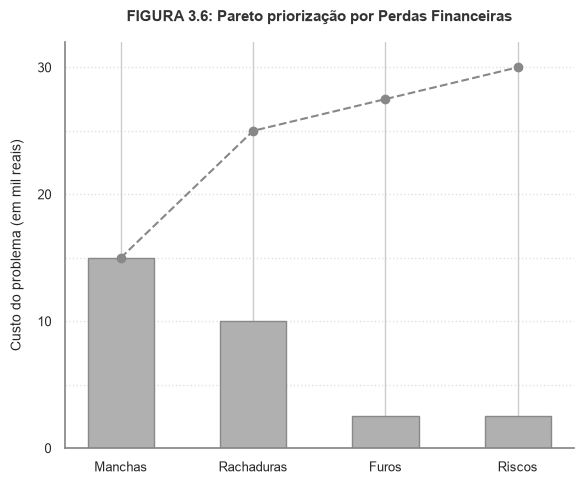

In [64]:

# =========================================================================
# FIGURA 3.6: Pareto por Custo com Linha de Acumulado (Barras Verticais)
# =========================================================================
fig2, ax2 = plt.subplots(figsize=(6, 5))

# Dados estimados a partir da imagem
categorias_36 = ['Manchas', 'Rachaduras', 'Furos', 'Riscos']
custos_36 = [15, 10, 2.5, 2.5]

# Cálculo do acumulado
acumulado_36 = np.cumsum(custos_36)

# Plotagem das barras (eixo esquerdo)
ax2.bar(categorias_36, custos_36, color='#B0B0B0', edgecolor='#888888', width=0.5)
ax2.set_ylabel('Custo do problema (em mil reais)', fontsize=10, labelpad=10)
ax2.set_ylim(0, 32)
ax2.set_yticks([0, 10, 20, 30])

# Captura os eixos atuais para aplicar a paginação do eixo Y
ax = plt.gca()

# Define os labels/linhas principais a cada 10 e as linhas secundárias a cada 5
ax.yaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_minor_locator(MultipleLocator(5))

# Aplica o grid pontilhado tanto nas linhas principais quanto nas secundárias
plt.grid(axis = "y", which = "both", linestyle = ":", alpha = 0.6)

# Criar um segundo eixo para a linha de acumulado (mas mantendo a mesma escala visual do custo)
# Na imagem, a linha indica o valor acumulado no próprio eixo do custo (vai até ~27)
ax2.plot(categorias_36, acumulado_36, color='#888888', marker='o', linestyle='--', linewidth=1.5)

# Ajuste de bordas
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#888888')
ax2.spines['bottom'].set_color('#888888')
ax2.tick_params(axis='both', which='major', labelsize=9)

plt.title('FIGURA 3.6: Pareto priorização por Perdas Financeiras', fontsize=11, weight='bold', pad=15)
plt.tight_layout()

# Exibir os gráficos
plt.show()

## EXERCÍCIOS DA SEÇÃO
Considere o objetivo de verificar a demanda da qualidade no desenvolvimento de um software. Em uma pesquisa de mercado, indagaram-se aos clientes potenciais qual dos seguintes itens era considerado mais importante: (a) interface de fácil acesso, (b) desempenho do sistema, (c) métodos de análise avançados, (d) método de custeio, (e) manutenção e suporte, (f) personalização, (g) atualização em tempo real, (h) confiabilidade das informações, (i) segurança dos dados e (j) uso de novas tecnologias de informática.3 As frequências de resposta foram (a) 8, (b) 7, (c) 7, (d) 12, (e) 2, (f) 4, (g) 3, (h) 21, (i) 6 e (j) 0, respectivamente.
a)A variável demanda da qualidade no desenvolvimento de um software, operacionalizada de acordo com a pergunta feita aos clientes, é qualitativa ou quantitativa?

b)Construa um diagrama que mostre a distribuição de frequências das respostas, priorizando os itens segundo a frequência de respostas. Qual o nome que se dá a este diagrama?

In [68]:
import pandas as pd

# 1. Definição dos dados coletados no exercício (Categorias e Frequências)
dados = {
    "Categoria": [
        "a) interface fácil",
        "b) desemp. sist.",
        "c) métodos anal. avançados",
        "d) método custeio",
        "e) manutenção e suporte",
        "f) personalização",
        "g) atual. tempo real",
        "h) confiabilidade da info.",
        "i) segurança dos dados (LGPD)",
        "j) uso novas tecnologias de informática"
    ],
    "Frequencia_Absoluta (fi)": [8, 7, 7, 12, 2, 4, 3, 21, 6, 0]
}

# 2. Criar o DataFrame (Tabela)
df = pd.DataFrame(dados)

# 3. Calcular a Frequência Relativa (fr) e a Frequência Percentual (fr %)
total_observacoes = df["Frequencia_Absoluta (fi)"].sum()
df["Frequencia_Relativa (fr)"] = df["Frequencia_Absoluta (fi)"] / total_observacoes
df["Frequencia_Percentual (%)"] = df["Frequencia_Relativa (fr)"] * 100

# 4. Identificar a Moda (Categoria com maior frequência)
linha_moda = df.loc[df["Frequencia_Absoluta (fi)"].idxmax()]
moda_categoria = linha_moda["Categoria"]
moda_frequencia = linha_moda["Frequencia_Absoluta (fi)"]

# 5. Exibir os resultados na tela
print("--- TABELA DE FREQUÊNCIAS ---")
print(df.to_string(index=False))
print("\n" + "="*50)
print(f"Total de observações (N): {total_observacoes}")
print(f"Moda: {moda_categoria} (Frequência: {moda_frequencia})")
print("="*50)

--- TABELA DE FREQUÊNCIAS ---
                              Categoria  Frequencia_Absoluta (fi)  Frequencia_Relativa (fr)  Frequencia_Percentual (%)
                     a) interface fácil                         8                  0.114286                  11.428571
                       b) desemp. sist.                         7                  0.100000                  10.000000
             c) métodos anal. avançados                         7                  0.100000                  10.000000
                      d) método custeio                        12                  0.171429                  17.142857
                e) manutenção e suporte                         2                  0.028571                   2.857143
                      f) personalização                         4                  0.057143                   5.714286
                   g) atual. tempo real                         3                  0.042857                   4.285714
             h) co

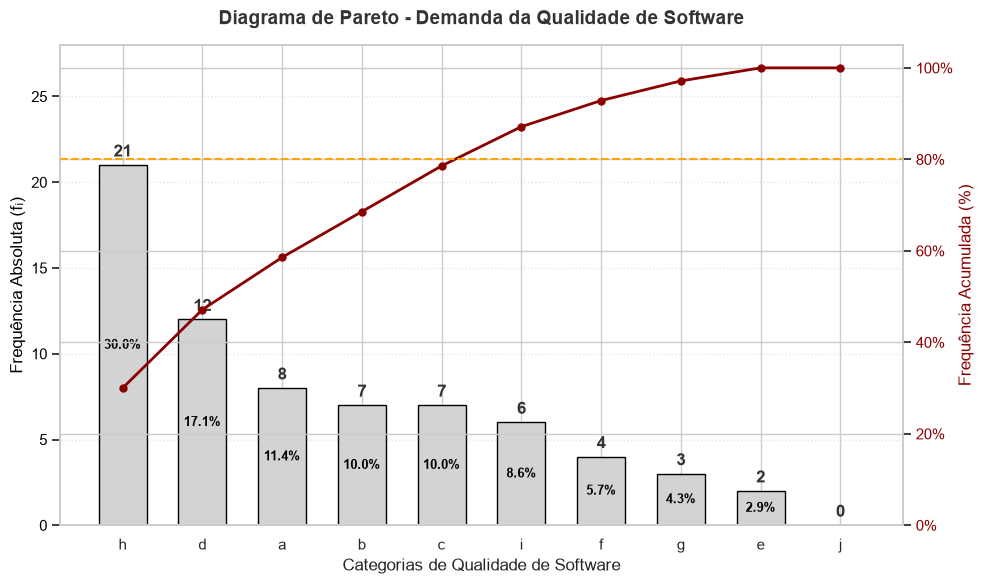

In [70]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

# 1. Definição dos dados coletados na imagem anterior
dados = {
    "Categoria": ["h", "d", "a", "b", "c", "i", "f", "g", "e", "j"],
    "Frequencia": [21, 12, 8, 7, 7, 6, 4, 3, 2, 0]
}

# Criar o DataFrame e garantir a ordenação decrescente pelas frequências
df = pd.DataFrame(dados)
df = df.sort_values(by="Frequencia", ascending=False).reset_index(drop=True)

# 2. Calcular o percentual por categoria e a porcentagem acumulada
df["Percentual"] = (df["Frequencia"] / df["Frequencia"].sum()) * 100
df["Percentual_Acumulado"] = (df["Frequencia"].cumsum() / df["Frequencia"].sum()) * 100

# 3. Configuração do gráfico com dois eixos Y
fig, ax1 = plt.subplots(figsize=(10, 6))

# Eixo Y Primário (Esquerda) - Gráfico de Colunas / Barras
cor_barras = "lightgray"
bars = ax1.bar(df["Categoria"], df["Frequencia"], color=cor_barras, edgecolor="black", width=0.6)
ax1.set_xlabel("Categorias de Qualidade de Software", fontsize=12)
ax1.set_ylabel("Frequência Absoluta (fᵢ)", color="black", fontsize=12)
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_ylim(0, df["Frequencia"].sum() * 0.4) # Margem superior para visualização

# Adicionar rótulos: frequência no topo e percentual dentro da coluna (exceto a última)
for i, (bar, v, pct) in enumerate(zip(bars, df["Frequencia"], df["Percentual"])):
    ax1.text(i, v + 0.5, str(v), ha="center", fontweight="bold")
    if i < len(df) - 1 and v > 0:
        ax1.text(
            i,
            v / 2,
            f"{pct:.1f}%",
            ha="center",
            va="center",
            color="black",
            fontweight="bold",
            fontsize=9
        )

# Eixo Y Secundário (Direita) - Curva Acumulada
ax2 = ax1.twinx()
cor_linha = "darkred"
ax2.plot(df["Categoria"], df["Percentual_Acumulado"], color=cor_linha, marker="o", ms=5, linewidth=2)
ax2.set_ylabel("Frequência Acumulada (%)", color=cor_linha, fontsize=12)
ax2.tick_params(axis="y", labelcolor=cor_linha)
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylim(0, 105)

# 4. Adicionar a Linha de Corte de Pareto em 80%
ax2.axhline(80, color="orange", linestyle="--", linewidth=1.5, label="Corte de Pareto (80%)")

# Título e ajustes finais
plt.title("Diagrama de Pareto - Demanda da Qualidade de Software", fontsize=14, fontweight="bold", pad=15)
ax1.grid(axis="y", linestyle=":", alpha=0.5)

# Exibir o gráfico
plt.tight_layout()
plt.show()

## 3.3 DISTRIBUIÇÃO DE FREQUÊNCIAS PARA VARIÁVEIS QUANTITATIVAS
As variáveis quantitativas podem estar associadas a uma contagem, como o número de defeitos em itens que saem de uma linha de produção. Neste caso, os possíveis resultados podem ser listados (0, 1, 2, ...), formando um conjunto enumerável. Outras vezes, a variável está associada a uma mensuração, como no estudo da resistência mecânica de um novo material, em que se mede a resistência em corpos de prova do material. Neste caso, o resultado de cada ensaio pode ser qualquer valor em um intervalo de números reais, como em [0, ∞[.

Uma variável quantitativa é dita discreta se seus possíveis valores formam um conjunto finito ou infinito enumerável. É dita contínua se, teoricamente, pode ter como resultado qualquer valor em um intervalo de números reais.

### 3.3.1 Variáveis discretas
Desde que a quantidade de valores observados não seja muito grande, a distribuição de frequências de variáveis discretas pode ser feita de maneira análoga à de variáveis qualitativas. Porém, como os valores da variável formam uma escala numérica, graficamente temos um par de eixos cartesianos. Por convenção, o eixo horizontal representa a variável e o eixo vertical, as frequências. O gráfico apropriado para esse tipo de variável é formado por hastes com altura igual à frequência (absoluta ou relativa) de ocorrência do valor (ver Figura 3.7).

Observando o gráfico, notamos que as ocorrências predominam na faixa de zero a três defeitos. Também é possível observar que houve um caso com número de defeitos igual a oito, que é discrepante com relação aos outros casos. Além disso, vemos maior concentração de ocorrências na parte inferior da escala, mostrando uma distribuição assimétrica.


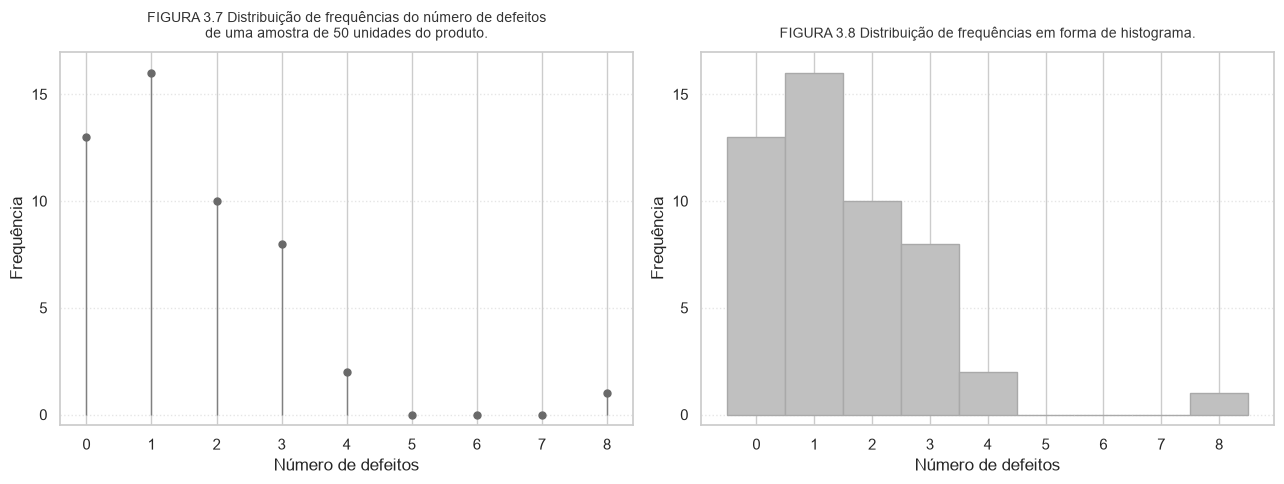

In [75]:
import matplotlib.pyplot as plt
import numpy as np

# Dados extraídos dos gráficos das figuras 3.7 e 3.8 (N = 50)
defeitos = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])
frequencias = np.array([13, 16, 10, 8, 2, 0, 0, 0, 1])

# Configuração da área de plotagem para colocar os dois gráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))


# ---------------------------------------------------------------------------
# GRÁFICO 1: FIGURA 3.7 - Distribuição de frequências do número de defeitos
# ---------------------------------------------------------------------------
# Desenha as linhas verticais finas (gráfico de hastes/agulhas)
ax1.vlines(defeitos, ymin=0, ymax=frequencias, colors="gray", linewidth=1)
# Desenha os pontos no topo de cada linha
ax1.plot(defeitos, frequencias, "o", color="dimgray", markersize=5)

# Customizações do Gráfico 1
ax1.set_title("FIGURA 3.7 Distribuição de frequências do número de defeitos\nde uma amostra de 50 unidades do produto.", fontsize=10, pad=10)
ax1.set_xlabel("Número de defeitos")
ax1.set_ylabel("Frequência")
ax1.set_xticks(defeitos)
ax1.set_yticks([0, 5, 10, 15])
ax1.set_ylim(-0.5, 17)
ax1.grid(True, axis="y", linestyle=":", alpha=0.5)


# ---------------------------------------------------------------------------
# GRÁFICO 2: FIGURA 3.8 - Distribuição de frequências em forma de histograma
# ---------------------------------------------------------------------------
# Retângulos justapostos (width=1.0 elimina o espaço entre as barras)
# O parâmetro align='center' posiciona o número bem no centro da base
ax2.bar(defeitos, frequencias, width=1.0, color="silver", edgecolor="darkgray", align="center")

# Customizações do Gráfico 2
ax2.set_title("FIGURA 3.8 Distribuição de frequências em forma de histograma.", fontsize=10, pad=10)
ax2.set_xlabel("Número de defeitos")
ax2.set_ylabel("Frequência")
ax2.set_xticks(defeitos)
ax2.set_yticks([0, 5, 10, 15])
ax2.set_ylim(-0.5, 17)
ax2.grid(True, axis="y", linestyle=":", alpha=0.5)


# Ajustar o espaçamento para não cortar os textos e exibir
plt.tight_layout()
plt.show()

FIGURA 3.7 Distribuição de frequências do número de defeitos de uma amostra de 50 unidades do produto.  
e  
FIGURA 3.8 Distribuição de frequências em forma de histograma.

Outra forma de apresentação é usando o formato do que chamamos de histograma. Construímos retângulos justapostos de alturas iguais às frequências, sendo que cada valor observado é situado no centro da base desses retângulos, como na Figura 3.8.


### 3.3.2 Variáveis contínuas

Nesta seção, apresentaremos algumas formas de se fazer uma distribuição de frequências de dados contínuos.

#### TABELA DE FREQUÊNCIAS
Para construir uma tabela de frequências, dividimos a amplitude total dos dados (diferença entre o maior e o menor valor) em vários intervalos, denominados classes. As classes devem ser mutuamente exclusivas, exaustivas e, de preferência, de mesmo tamanho.

#### EXEMPLO 3.2

Os dados que se seguem são observações do tempo (em segundos) da carga de um aplicativo, em um sistema compartilhado (50 observações):

In [77]:
import pandas as pd
import numpy as np

# Total 50 valores
# Lista original contendo os 50 valores fornecidos
dados = [
    5.2, 6.4, 5.7, 8.3, 7.0, 5.4, 4.8, 9.1, 5.5, 6.2,
    4.9, 5.7, 6.3, 5.1, 8.4, 6.2, 8.9, 7.3, 5.4, 4.8,
    5.6, 6.8, 5.0, 6.7, 8.2, 7.1, 4.9, 5.0, 8.2, 9.9,
    5.4, 5.6, 5.7, 6.2, 4.9, 5.1, 6.0, 4.7, 14.1, 5.3,
    4.9, 5.0, 5.7, 6.3, 6.0, 6.8, 7.3, 6.9, 6.5, 5.9
]

# Reorganiza a lista unidimensional em uma matriz de 5 linhas por 10 colunas
matriz = np.array(dados).reshape(5, 10)

# Define os nomes das colunas de forma personalizada (de Coluna_1 até Coluna_10)
nomes_colunas = [f"Col_{i+1}" for i in range(10)]

# Converte a matriz de dados numéricos em um DataFrame do Pandas
tabela = pd.DataFrame(matriz, columns=nomes_colunas)

# Configura o Pandas no terminal para exibir todas as colunas sem quebrar linhas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Exibe a tabela estruturada na tela
print(tabela)


   Col_1  Col_2  Col_3  Col_4  Col_5  Col_6  Col_7  Col_8  Col_9  Col_10
0    5.2    6.4    5.7    8.3    7.0    5.4    4.8    9.1    5.5     6.2
1    4.9    5.7    6.3    5.1    8.4    6.2    8.9    7.3    5.4     4.8
2    5.6    6.8    5.0    6.7    8.2    7.1    4.9    5.0    8.2     9.9
3    5.4    5.6    5.7    6.2    4.9    5.1    6.0    4.7   14.1     5.3
4    4.9    5.0    5.7    6.3    6.0    6.8    7.3    6.9    6.5     5.9


O valor mínimo desse conjunto de observações é igual a 4,7 e o máximo é igual a 14,1. Então, vamos dividir esse intervalo em várias classes. Por simplicidade, consideremos classes de amplitude igual a 1 e iniciando por 4,0, conforme ilustra a Figura 3.9. Posteriormente, voltaremos à discussão sobre o número de classes e suas amplitudes.

![Divisão da amplitude dos dados em classes mutuamente exclusivas e exaustivas.](fig/amplitude_particao_11_classes.png)

FIGURA 3.9 Divisão da amplitude dos dados em classes mutuamente exclusivas e exaustivas.  

O passo seguinte é contar quantos valores estão em cada classe previamente estabelecida. Como os dados são arredondados para um número finito de decimais, podem ocorrer valores exatamente no limite entre duas classes. Por convenção, consideraremos o intervalo fechado no limite inferior e aberto no limite superior. A primeira classe, por exemplo, é formada pelo intervalo [4,0; 5,0), ou 4 |— 5, conforme a simbologia comumente usada em Estatística.  

A tabela de frequências é construída mediante a contagem da frequência de observações em cada classe. A primeira coluna da Tabela 3.2 mostra a lista das classes; a segunda coluna contém o ponto médio de cada classe (média aritmética dos limites da classe); a terceira coluna apresenta a quantidade de ocorrências em cada classe, obtida pela contagem; a quarta coluna contém as frequências relativas; e a última coluna, as frequências acumuladas. Sendo c o número de classes e n o número de observações, os cálculos para obtenção dos valores das duas últimas colunas são, respectivamente:


In [79]:
import pandas as pd
import numpy as np

# Dados fornecidos
dados = [
    5.2, 6.4, 5.7, 8.3, 7.0, 5.4, 4.8, 9.1, 5.5, 6.2,
    4.9, 5.7, 6.3, 5.1, 8.4, 6.2, 8.9, 7.3, 5.4, 4.8,
    5.6, 6.8, 5.0, 6.7, 8.2, 7.1, 4.9, 5.0, 8.2, 9.9,
    5.4, 5.6, 5.7, 6.2, 4.9, 5.1, 6.0, 4.7, 14.1, 5.3,
    4.9, 5.0, 5.7, 6.3, 6.0, 6.8, 7.3, 6.9, 6.5, 5.9
]

# Definindo os limites das 11 classes (de 4 a 15 com amplitude h = 1)
limites_bins = list(range(4, 16))

# Rotulos dos intervalos no formato [a |- b) (fechado à esquerda, aberto à direita)
rotulos_classes = [f"[{i} |- {i+1})" for i in range(4, 15)]

# Cálculo do Ponto Médio (xi) para cada uma das classes: (limite_inferior + limite_superior) / 2
pontos_medios = [(i + (i + 1)) / 2 for i in range(4, 15)]

# Classificação dos dados dentro dos intervalos estabelecidos
classes_categorizadas = pd.cut(
    dados, bins=limites_bins, right=False, labels=rotulos_classes
)

# Frequência Absoluta (fi): contagem de elementos em cada classe
frequencia_absoluta = (
    pd.Series(classes_categorizadas)
    .value_counts()
    .reindex(rotulos_classes, fill_value=0)
)

# Frequência Relativa em % (fr %)
frequencia_relativa_pct = (frequencia_absoluta / len(dados)) * 100

# Frequência Acumulada Absoluta (Fi)
frequencia_acumulada_absoluta = frequencia_absoluta.cumsum()

# Frequência Relativa Acumulada em % (FR %) - Última coluna
frequencia_relativa_acumulada_pct = (
    frequencia_acumulada_absoluta / len(dados)
) * 100

# Montagem do DataFrame final com todas as colunas requisitadas
tabela_frequencias = pd.DataFrame({
    'Classe': rotulos_classes,
    'Ponto Médio (xi)': pontos_medios,
    'fi (Absoluta)': frequencia_absoluta.values,
    'fr % (Relativa)': frequencia_relativa_pct.values,
    'Fi (Acumulada Absoluta)': frequencia_acumulada_absoluta.values,
    'FR % (Freq Rel Acumulada %)': frequencia_relativa_acumulada_pct.values,
})

# Configuração de exibição do Pandas para visualização completa no console
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Exibição do resultado final
print("--- TABELA DE DISTRIBUIÇÃO DE FREQUÊNCIAS COMPLETA ---")
print(tabela_frequencias.to_string(index=False))

--- TABELA DE DISTRIBUIÇÃO DE FREQUÊNCIAS COMPLETA ---
    Classe  Ponto Médio (xi)  fi (Absoluta)  fr % (Relativa)  Fi (Acumulada Absoluta)  FR % (Freq Rel Acumulada %)
  [4 |- 5)               4.5              7             14.0                        7                         14.0
  [5 |- 6)               5.5             18             36.0                       25                         50.0
  [6 |- 7)               6.5             13             26.0                       38                         76.0
  [7 |- 8)               7.5              4              8.0                       42                         84.0
  [8 |- 9)               8.5              5             10.0                       47                         94.0
 [9 |- 10)               9.5              2              4.0                       49                         98.0
[10 |- 11)              10.5              0              0.0                       49                         98.0
[11 |- 12)              1

TABELA 3.2 Distribuição de frequências do tempo (em segundos) para a carga de um aplicativo, em um sistema compartilhado


### HISTOGRAMA
O histograma é a forma usual de apresentação de distribuição de frequências de variável contínua. A Figura 3.10 mostra um histograma, construído a partir da Tabela 3.2. São retângulos justapostos sobre as classes da variável em estudo. A altura de cada retângulo deve ser igual (ou proporcional) à frequência observada na classe. Formalmente, a escala do eixo vertical deve ser ajustada para que a soma das áreas dos retângulos seja igual a um. Isso ocorre quando usamos no eixo vertical a frequência relativa dividida pela amplitude da classe, que resulta na chamada densidade de frequência (ver Figura 3.10).5 Na maioria das vezes, contudo, o histograma é apresentado com frequências absolutas no eixo vertical.

O histograma mostra que, na maioria das vezes, o tempo para a carga do aplicativo é inferior a 7 segundos. Destaca-se um ponto discrepante, indicando um caso diferenciado com tempo de carga superior a 14 segundos, que pode ser examinado separadamente dos demais, já que pode ter ocorrido alguma situação de anormalidade. O histograma também mostra que a distribuição do tempo de carga é assimétrica, com cauda mais longa do lado direito. Essa assimetria indica que intervalos de tempo baixo têm maior intensidade de ocorrências do que intervalos, de mesmo tamanho, de tempo alto.


FIGURA 3.10 Distribuição de frequências de 50 observações do tempo de carga de um aplicativo.
### SOBRE O NÚMERO DE CLASSES
O número de classes é uma escolha arbitrária. Quanto maior o conjunto de dados, mais classes podem ser usadas. Uma tabela ou gráfico com poucas classes apresenta a distribuição de forma bastante resumida, podendo deixar de evidenciar características relevantes. Por outro lado, se usarmos muitas classes, a tabela ou o gráfico pode não realçar aspectos importantes da distribuição de frequências.

Uma referência sobre o número de classes adotado por vários softwares é creditada a Sturges, que sugere:

Número de classes = 1 + 3,322 × log_10 (n)


Aplicando no nosso exemplo em que n = 50, a expressão resulta em, aproximadamente, sete classes, com amplitude igual a (14,1 – 4,7)/7 = 1,4.6 Se iniciarmos no valor mínimo, o intervalo formado pelas classes atinge o valor: 4,7 + 7 × 1,4 = 14,5; ou seja, 0,4 ponto superior ao valor máximo do conjunto de dados, que é 14,1. Sugere-se, então, iniciar as classes em 4,7 – 0,4/2 = 4,5; de modo a equilibrar a sobra nos dois extremos. Assim, têm-se as classes: 4,5 |— 5,9; 5,9 |— 7,3; e assim por diante, até a sétima classe: 12,9 |— 14,3.

A fórmula de Sturges fornece bom número de classes se a distribuição de frequências for razoavelmente simétrica e não houver valor(es) discrepante(s). Em nosso exemplo, como há valor discrepante, maior quantidade de classes é recomendada.

Para variáveis discretas, com grande quantidade de valores distintos, também podemos agrupá-los em classes. Neste caso, contudo, devemos fazer a divisão das classes de modo a garantir que elas englobem a mesma quantidade de possíveis resultados da variável.

### GRÁFICO DE FREQUÊNCIAS ACUMULADAS
Muitas vezes, o maior interesse está nas frequências de observações menores que um dado valor. A Figura 3.11 mostra o gráfico das frequências relativas acumuladas, sendo no eixo horizontal os valores da variável em estudo, conforme as classes indicadas na primeira coluna da Tabela 3.2; no eixo vertical, são as porcentagens acumuladas que estão na última coluna dessa tabela.

A linha tracejada no gráfico da Figura 3.11 indica, como ilustração, a porcentagem de observações com tempo de carga inferior a 7 segundos.


FIGURA 3.11 Distribuição acumulada de frequências, em porcentagem, feita com os dados agrupados.
As frequências acumuladas podem ser definidas de maneira mais rigorosa com os dados não grupados em classes, mas somente ordenados, como mostra a Figura 3.12.7 Chamando de n(x) o número de observações menores ou iguais a x, a frequência de observações até o valor x é dada por:



FIGURA 3.12 Distribuição acumulada de frequências, a partir de dados individuais.
### DIAGRAMA DE PONTOS
No histograma, agrupamos as observações em classes, mas podemos fazer o gráfico sem esse agrupamento, particularmente quando se está trabalhando com pequena quantidade de observações. No diagrama de pontos, representamos cada valor como um ponto na reta de números reais, como ilustra a Figura 3.13, considerando os dados do Exemplo 3.2.


FIGURA 3.13 Diagrama de pontos do tempo de carga de um aplicativo.
O diagrama de pontos pode ser usado para comparar os resultados de uma variável contínua observada em diferentes condições. Considere um estudo experimental sobre um processo químico, do qual queremos avaliar o rendimento em dois níveis de temperatura da reação: 60 e 80 °C. Os dados de rendimento (%) foram:

## 4. Medidas de Posição Central e Dispersão

In [ ]:
# Cálculo das Estatísticas Descritivas Principais
media = np.mean(dados_quantitativos)
mediana = np.median(dados_quantitativos)
variancia = np.var(dados_quantitativos, ddof=1) # ddof=1 para variância amostral
desvio_padrao = np.std(dados_quantitativos, ddof=1)
coef_variacao = (desvio_padrao / media) * 100
amplitude = np.max(dados_quantitativos) - np.min(dados_quantitativos)

print(f"Média: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Amplitude Total: {amplitude:.2f}")
print(f"Variância Amostral: {variancia:.2f}")
print(f"Desvio Padrão Amostral: {desvio_padrao:.2f}")
print(f"Coeficiente de Variação: {coef_variacao:.2f}%")

Média: 49.37
Mediana: 48.84
Amplitude Total: 80.00
Variância Amostral: 124.17
Desvio Padrão Amostral: 11.14
Coeficiente de Variação: 22.57%


## 5. Diagrama de Caixa (Boxplot) e Identificação de Outliers

Primeiro Quartil (Q1): 43.99
Terceiro Quartil (Q3): 55.05
Amplitude Interquartílica (IQR): 11.06


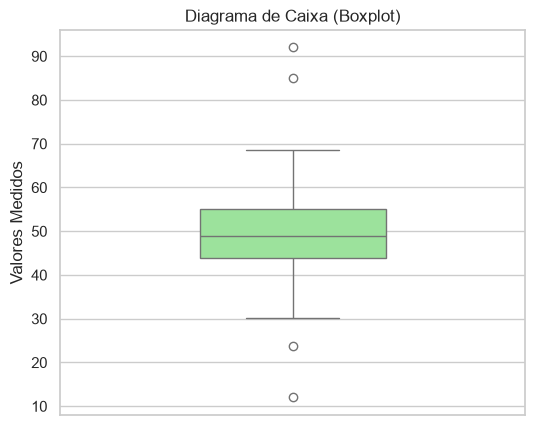

In [ ]:
# Visualização e cálculo dos Quartis
q1 = np.percentile(dados_quantitativos, 25)
q3 = np.percentile(dados_quantitativos, 75)
iqr = q3 - q1

print(f"Primeiro Quartil (Q1): {q1:.2f}")
print(f"Terceiro Quartil (Q3): {q3:.2f}")
print(f"Amplitude Interquartílica (IQR): {iqr:.2f}")

# Gerando o Boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(y=dados_quantitativos, color='lightgreen', width=0.4)
plt.title('Diagrama de Caixa (Boxplot)')
plt.ylabel('Valores Medidos')
plt.show()